# Healthcare ML Platform
## Notebook 01 — EDA: Medical Insurance Cost Dataset

**Dataset:** Medical Cost Personal Dataset (Kaggle)  
**Rows:** 1,338 patients  
**Target:** `charges` — annual medical insurance cost in USD  


---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

---
## Step 1 — Load and Inspect the Data

In [4]:
df = pd.read_csv(r"G:\healthcare\Dataset\raw\insurance.csv")
print(f"Shape : { df.shape}")
print(f"Columns : { list(df.columns)}")
print(f"\nFirst 5 rows")
df.head()

Shape : (1338, 7)
Columns : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
# summary
numeric_df = df[["age","bmi","children","charges"]]
summary = pd.DataFrame({
    "Max":numeric_df.max(),
    "Min":numeric_df.min(),
    "Range":numeric_df.max()-numeric_df.min(),
    "Mean":numeric_df.mean(),
    "Median":numeric_df.median(),
    "Mode":numeric_df.mode().iloc[0],
    "Std_Dev":numeric_df.std()
})
summary

,Max,Min,Range,Mean,Median,Mode,Std_Dev
age,64.00000,18.0000,46.00000,39.207025,39.000,18.0000,14.049960
bmi,53.13000,15.9600,37.17000,30.663397,30.400,32.3000,6.098187
children,5.00000,0.0000,5.00000,1.094918,1.000,0.0000,1.205493
charges,63770.42801,1121.8739,62648.55411,13270.422265,9382.033,1639.5631,12110.011237


---
## Step 2 — Understand Each Feature

| Column | Type | Description | Notes |
|---|---|---|---|
| `age` | Numeric | Patient age in years | Range: 18–64 |
| `sex` | Categorical | male / female | Need to encode |
| `bmi` | Numeric | Body Mass Index | Healthy range: 18.5–24.9 |
| `children` | Numeric | Number of dependents | 0–5 |
| `smoker` | Categorical | yes / no | Most important predictor |
| `region` | Categorical | US region | 4 values: northeast/northwest/southeast/southwest |
| `charges` | Numeric | Annual insurance cost USD | **This is our target** |


In [ ]:
print("Missing Values: ")
print(df.isnull().sum())
print(f"\nTotal Missing : {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

#Remove duplicate row 
df =df.drop_duplicates()
print(f"\nNew Shape: {df.shape}")

Missing Values: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing : 0
Duplicate rows: 1
New Shape: (1337, 7)


---
## Step 3 — Visualise the Target Variable (charges)

The most important thing to understand before regression  
is the **distribution of the target**.

If it is heavily skewed, a log transformation often helps  
linear models significantly — though tree-based models  
like XGBoost handle skew naturally without transformation.

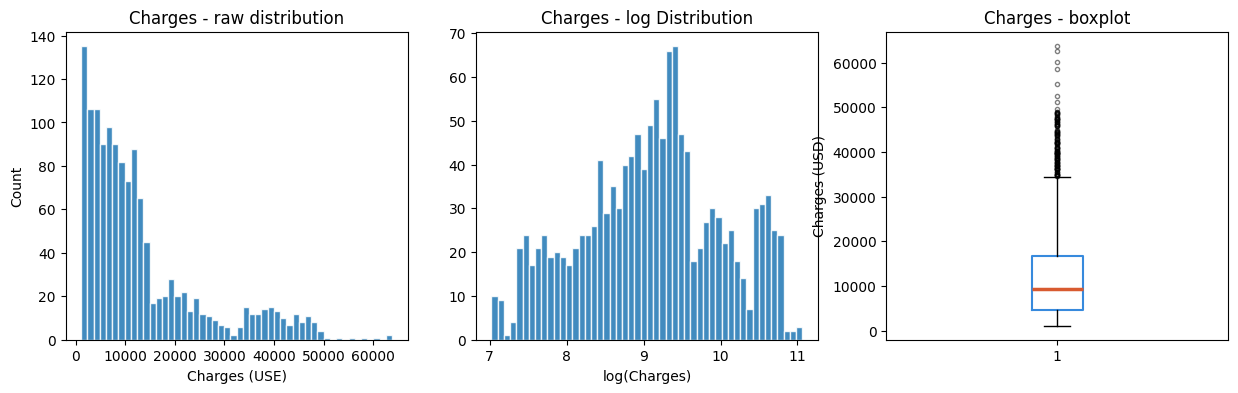

In [21]:
from turtle import color


fig,axes = plt.subplots(1,3,figsize=(15,4))

#Raw distribution
axes[0].hist(df['charges'],bins = 50,edgecolor = "white",alpha=0.85)
axes[0].set_title("Charges - raw distribution")
axes[0].set_xlabel("Charges (USE)")
axes[0].set_ylabel("Count")

#Log distribution
axes[1].hist(np.log1p(df['charges']),bins=50,edgecolor='white',alpha=0.85)
axes[1].set_title("Charges - log Distribution")
axes[1].set_xlabel("log(Charges)")

#Boxplot
axes[2].boxplot(df['charges'],
                boxprops=dict(color="#378ADD", linewidth=1.5),
                medianprops=dict(color="#D85A30", linewidth=2.5),
                flierprops=dict(marker="o", color="#888780",
                                markersize=3, alpha=0.5))
axes[2].set_title("Charges - boxplot")
axes[2].set_ylabel("Charges (USD)")


plt.show()

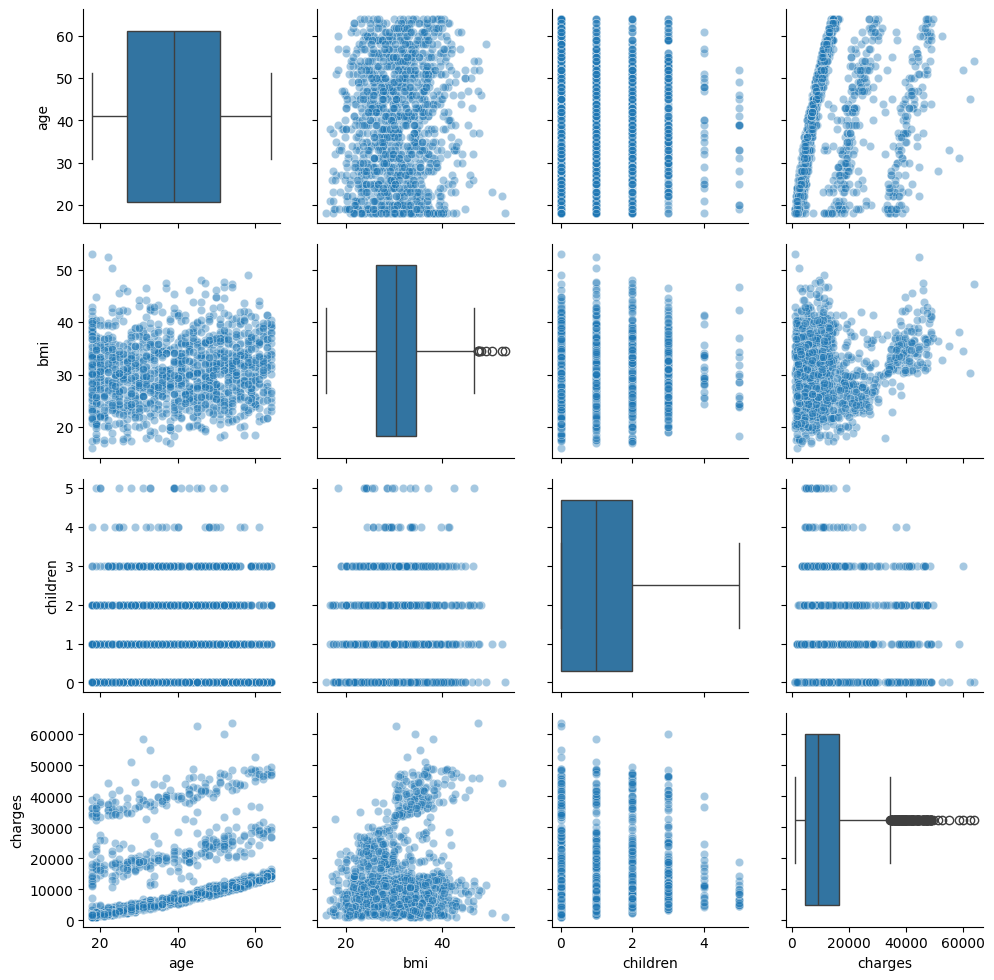

In [33]:
from pyparsing import alphanums


cols = ["age","bmi","children","charges"]
g=sns.PairGrid(df[cols])
g.map_offdiag(sns.scatterplot,alpha=0.4)
g.map_diag(sns.boxplot)
plt.show()

---
## Step 4 — The Smoker Effect

This is the most important relationship in the dataset.  
Smokers pay dramatically more than non-smokers.  
Understanding this drives our feature engineering decisions.

Charges by smoker status:
       Mean charges Median charges  Count
smoker                                   
no        $8,440.66      $7,345.73   1063
yes      $32,050.23     $34,456.35    274


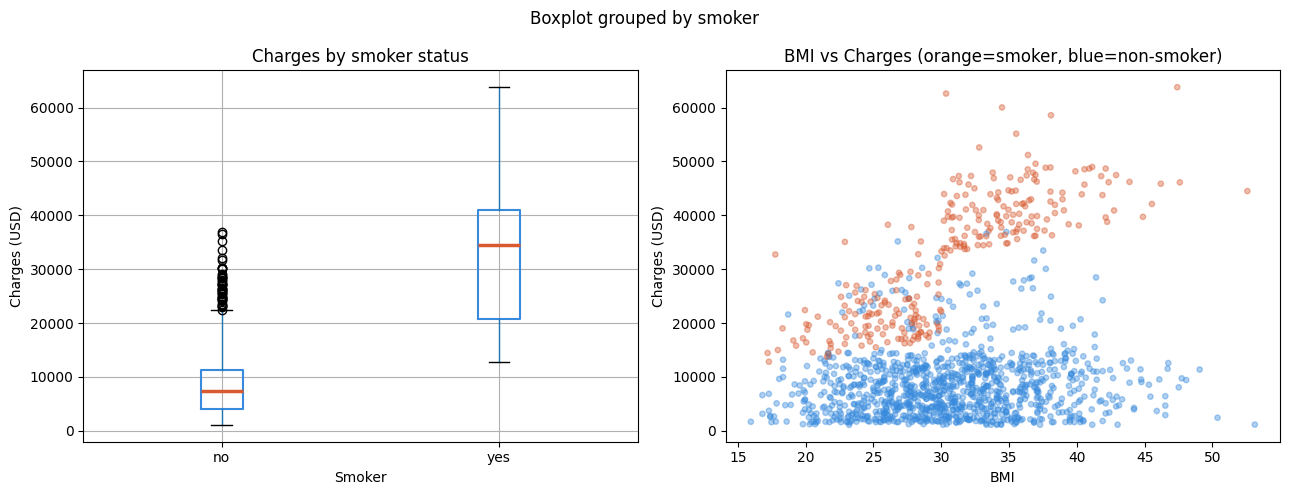

In [31]:
smoker_stats = df.groupby("smoker")["charges"].agg(["mean","median","count"])
smoker_stats.columns = ["Mean charges","Median charges","Count"]
smoker_stats["Mean charges"] = smoker_stats["Mean charges"].apply(lambda x: f"${x:,.2f}")
smoker_stats["Median charges"] = smoker_stats["Median charges"].apply(lambda x: f"${x:,.2f}")
print("Charges by smoker status:")
print(smoker_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot by smoker
df.boxplot(column="charges", by="smoker", ax=axes[0],
           boxprops=dict(color="#378ADD", linewidth=1.5),
           medianprops=dict(color="#D85A30", linewidth=2.5))
axes[0].set_title("Charges by smoker status")
axes[0].set_xlabel("Smoker")
axes[0].set_ylabel("Charges (USD)")

# Scatter — BMI vs charges, colored by smoker
colors = df["smoker"].map({"yes": "#D85A30", "no": "#378ADD"})
axes[1].scatter(df["bmi"], df["charges"], c=colors, alpha=0.4, s=15)
axes[1].set_title("BMI vs Charges (orange=smoker, blue=non-smoker)")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Charges (USD)")

plt.tight_layout()
plt.savefig("G:/healthcare/outputs/insurance_smoker.png", dpi=150)

plt.show()

The scatter plot shows two distinct clouds - smmokers(orange) sit much higher on the y-axis than non-smoker(blue). Within the smomker cloud, higher BMI pushes charges even higher.

---
## Step 6 — Correlation Analysis

We can only compute correlation for numeric columns.  
Categorical columns (sex, smoker, region) need encoding first.  
We encode them temporarily just for this analysis.

[[ True  True  True  True  True  True  True]
 [False  True  True  True  True  True  True]
 [False False  True  True  True  True  True]
 [False False False  True  True  True  True]
 [False False False False  True  True  True]
 [False False False False False  True  True]
 [False False False False False False  True]]


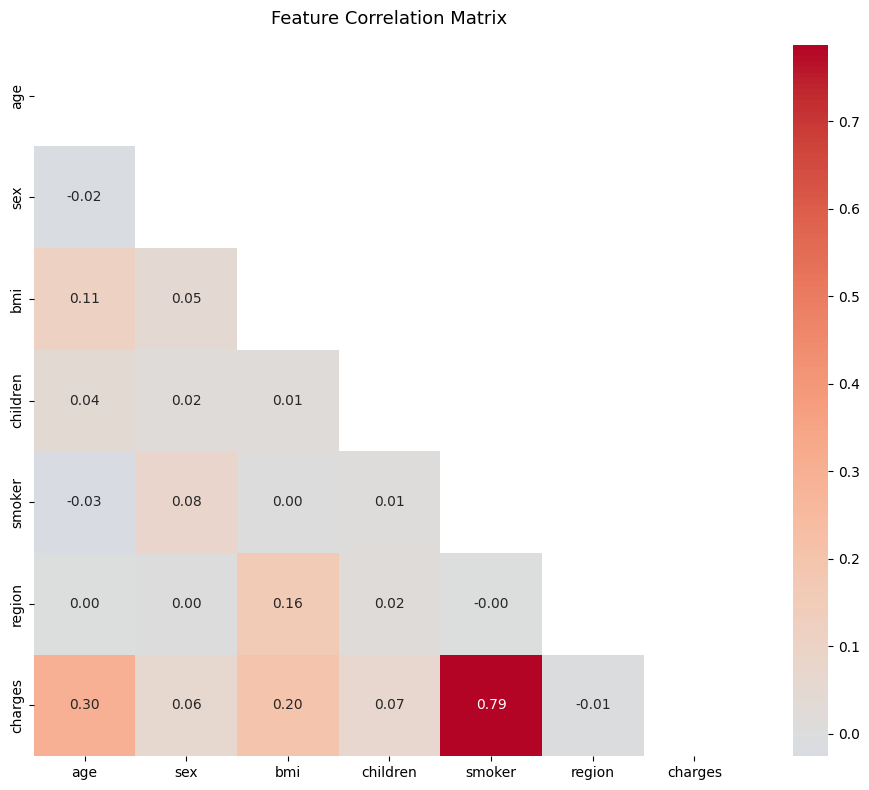

Correlation with charges (strongest predictors):
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
region     -0.006547


In [ ]:
# Temporary encoding for correlation analysis only
from numpy import core


df_corr = df.copy()
df_corr["smoker"]=df_corr['smoker'].map({"yes":1,"no":0})
df_corr["sex"]=df_corr['sex'].map({"male":1,"female":0})
df_corr["region"]=df_corr['region'].map({"northeast":0,"northwest":1,
                                         "southeast":2,"southwest":3})


plt.figure(figsize=(10,8))
corr=df_corr.corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt=".2f",
            cmap="coolwarm",center=0,square=True)
plt.title("Feature Correlation Matrix",fontsize=13,pad=15)
plt.tight_layout()
plt.savefig("G:/healthcare/outputs/insurance_correlation.png", dpi=150)
plt.show()


print("Correlation with charges (strongest predictors):")
print(corr["charges"].sort_values(ascending=False).to_string())

---
## Step 7 — Save Cleaned Dataset

In [36]:
os.makedirs("G:/healthcare/Dataset/processed", exist_ok=True)

df.to_csv("G:/healthcare/Dataset/processed/insurance_clean.csv", index=False)

print(f"Saved: insurance_clean.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn summary:")
for col in df.columns:
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    print(f"  {col:<12} dtype={str(dtype):<10} unique={n_unique}")

Saved: insurance_clean.csv
Shape: (1337, 7)

Column summary:
  age          dtype=int64      unique=47
  sex          dtype=object     unique=2
  bmi          dtype=float64    unique=548
  children     dtype=int64      unique=6
  smoker       dtype=object     unique=2
  region       dtype=object     unique=4
  charges      dtype=float64    unique=1337
